In [1]:
import os
import sys
import time
from typing import Optional, Sequence, Tuple, List

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import json

from openai import OpenAI

# Load environment variables from current directory .env and override existing ones
load_dotenv(".env", override=True)

# load api key from environment
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")
    
client = OpenAI(api_key=api_key)

In [2]:
df = pd.read_json("hf://datasets/HannahRoseKirk/prism-alignment/survey.jsonl", lines=True)

# Use the self-written constitution with respect to how participants want AI Language models to behave
mask_principles = df["system_string"].notna()
self_written_ai_principles = df.loc[mask_principles, "system_string"].tolist()
principle_df_indices = df.index[mask_principles].to_numpy()

In [3]:
def get_embedding(principle):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.embeddings.create(
                input=principle,
                model="text-embedding-3-small",
            )
            return response.data[0].embedding
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [4]:
def summarize_cluster(cluster, prompt, summary_prompt):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=[
                    {"role": "system", "content": summary_prompt},
                    {"role": "user", "content": prompt}
                ],
            )
            summary = response.choices[0].message.content.strip()
            return({
                "cluster_id": cluster["cluster_id"],
                "summarized_principle": summary,
                "original_principles": cluster["principles"]
            })
            break
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [5]:
emb_path = "self_written_ai_principles_embeddings.npy"

if os.path.exists(emb_path):
    print(f"Loading embeddings from {emb_path}")
    X = np.load(emb_path)
    X = np.asarray(X, dtype=np.float32)
else:
    print("No saved embeddings found. Computing embeddings now...")
    embeddings = []
    for p in tqdm(self_written_ai_principles, desc="Computing embeddings"):
        embeddings.append(get_embedding(p))

    X = np.vstack(embeddings)
    np.save(emb_path, X)
    print(f"Saved embeddings to {emb_path}")

print("Embeddings shape:", X.shape)

Loading embeddings from self_written_ai_principles_embeddings.npy
Embeddings shape: (1500, 1536)


In [6]:
def pairwise_distances(points):
    points = np.asarray(points, dtype=np.float32)
    sq_norms = np.sum(points ** 2, axis=1)
    D2 = sq_norms[:, None] + sq_norms[None, :] - 2.0 * (points @ points.T)
    D2 = np.maximum(D2, 0.0)
    return np.sqrt(D2)


def greedy_capture_fair_clustering(points, k):
    """Greedy Capture Algorithhm"""
    points = np.asarray(points, dtype=np.float32)
    n = points.shape[0]
    
    dist = pairwise_distances(points)  

    events = []
    for i in range(n):
        for j in range(n):
            events.append((dist[i, j], i, j))
    events.sort(key=lambda t: t[0])

    quota = int(np.ceil(n / k))
    remaining = set(range(n))
    open_centers = []
    ball_points = [set() for _ in range(n)]

    for d_ij, i, j in events:
        if not remaining:
            break
        if len(open_centers) >= k:
            break
        if i not in remaining:
            continue

        if j in open_centers:
            remaining.remove(i)
        else:
            ball_points[j].add(i)
            if len(ball_points[j]) >= quota:
                open_centers.append(j)
                for p in ball_points[j]:
                    if p in remaining:
                        remaining.remove(p)
                ball_points[j].clear()

    open_centers = np.array(open_centers, dtype=int)

    dist_to_open = dist[:, open_centers]
    labels = np.argmin(dist_to_open, axis=1)

    return open_centers, labels, dist

In [7]:
k = 10

center_idx_gc, labels_gc, dist_gc = greedy_capture_fair_clustering(X, k)

print("Greedy Capture")
print("  num_centers:", len(center_idx_gc))

Greedy Capture
  num_centers: 10


In [8]:
center_embed_indices_gc = center_idx_gc

center_df_indices_gc = principle_df_indices[center_embed_indices_gc]

cluster_reps_gc = pd.DataFrame({
    "cluster_id": np.arange(len(center_embed_indices_gc)),
    "df_index": center_df_indices_gc,
    "representative_principle": df.loc[center_df_indices_gc, "system_string"].values,
})

cluster_reps_gc.to_json("cluster_representatives_greedy_capture.json",
                        orient="records", force_ascii=False)
cluster_reps_gc



,cluster_id,df_index,representative_principle
0,0,682,The AI should provide honest and factual infor...
1,1,763,The AI model should be kind and helpful. If as...
2,2,986,The AI should always behave rationally and nev...
3,3,565,The AI language model should consistently exhi...
4,4,576,I believe the AI language model should consist...
5,5,594,The AI should consistently exhibit traits of r...
6,6,697,The AI model should be factual and to the poin...
7,7,605,The AI should come across as friendly yet neut...
8,8,1314,The AI language model should be impartial. It ...
9,9,1263,I would want the AI to always be factually cor...


In [9]:
clusters_output = []

for cluster_id, center_embed_idx in enumerate(center_embed_indices_gc):
    cluster_embed_indices = np.where(labels_gc == cluster_id)[0]

    # map to original df indices
    cluster_df_indices = principle_df_indices[cluster_embed_indices]
    center_df_idx = center_df_indices_gc[cluster_id]

    principles = df.loc[cluster_df_indices, "system_string"].tolist()
    representative_principle = df.loc[center_df_idx, "system_string"]

    clusters_output.append(
        {
            "cluster_id": int(cluster_id),
            "center_embed_index": int(center_embed_idx),   
            "center_df_index": int(center_df_idx),         
            "representative_principle": representative_principle,
            "principles": principles,                     
        }
    )


(array([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 2., 0.,
        0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 2.]),
 array([ 63.        ,  68.23333333,  73.46666667,  78.7       ,
         83.93333333,  89.16666667,  94.4       ,  99.63333333,
        104.86666667, 110.1       , 115.33333333, 120.56666667,
        125.8       , 131.03333333, 136.26666667, 141.5       ,
        146.73333333, 151.96666667, 157.2       , 162.43333333,
        167.66666667, 172.9       , 178.13333333, 183.36666667,
        188.6       , 193.83333333, 199.06666667, 204.3       ,
        209.53333333, 214.76666667, 220.        ]),
 <BarContainer object of 30 artists>)

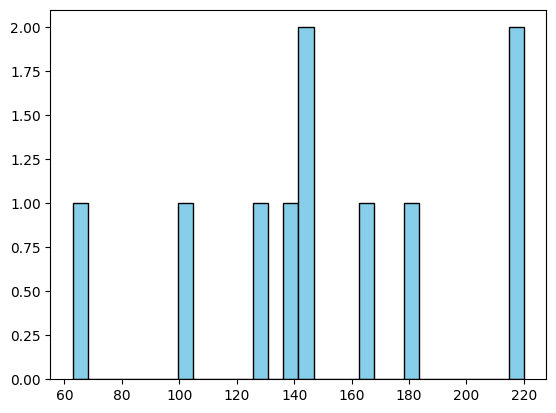

In [10]:
cluster_sizes = []
for cluster in clusters_output:
    cluster_sizes.append(len(cluster['principles']))


plt.hist(cluster_sizes, bins=30, color='skyblue', edgecolor='black')


In [23]:
with open('principle_summary_prompt.txt', 'r') as f:
    summary_prompt = f.read()
k = 3
summarized_principles = []

for cluster in tqdm(clusters_output):
    cluster_id = cluster["cluster_id"]
    center_embed_idx = cluster["center_embed_index"]

    cluster_embed_indices = np.where(labels_gc == cluster_id)[0]

    d_to_center = dist_gc[center_embed_idx, cluster_embed_indices]

    local_order = np.argsort(d_to_center)[:k]
    chosen_embed_indices = cluster_embed_indices[local_order]

    chosen_df_indices = principle_df_indices[chosen_embed_indices]
    closest_principles = df.loc[chosen_df_indices, "system_string"].tolist()

    principles_text = "\n".join(
        f"{i+1}. {p}" for i, p in enumerate(closest_principles)
    )
    prompt = f"\n\nPrinciples:\n{principles_text}\n\nSummarized Principle:"

    entry = summarize_cluster(cluster, prompt, summary_prompt)

    entry["representative_principle"] = cluster["representative_principle"]
    entry["center_df_index"] = cluster["center_df_index"]

    summarized_principles.append(entry)

with open("cluster_summarized_greedy_capture.json", "w", encoding="utf-8") as f:
    json.dump(summarized_principles, f, indent=4, ensure_ascii=False)



  0%|          | 0/10 [00:00<?, ?it/s]

In [24]:
print("10 summarized clusters using Greedy Capture")
for princ in summarized_principles:
    print("Summarized Principle: " + princ["summarized_principle"] + "\n")

10 summarized clusters using Greedy Capture
Summarized Principle: The AI should consistently communicate in a polite and friendly manner while providing accurate, unbiased, and factual information.

Summarized Principle: The AI should provide accurate, objective, and ethical information in a helpful, polite, and respectful manner, remaining neutral and unbiased while refusing to engage in harmful, unlawful, or inappropriate requests.

Summarized Principle: AI should interact with users in a strictly objective, rational, and factual manner, avoiding the expression of emotions, personal opinions, or biases, and should communicate clearly and concisely while remaining aware of legal boundaries and limitations of its knowledge.

Summarized Principle: An AI language model should consistently prioritize accuracy, impartiality, empathy, and ethical conduct, adapting its tone and creativity appropriately across contexts while safeguarding user privacy and refraining from generating harmful or 